In [17]:
from tqdm.autonotebook import tqdm
import pandas as pd
import numpy as np
import os
import shlex
import torch

if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from torch.utils.data import DataLoader
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
from BasisConvolution.util.dataloader import datasetLoader, processFolder
from BasisConvolution.util.augment import loadAugmentedFrame, loadAugmentedBatch
from BasisConvolution.util.network import buildModel, runInference


In [18]:
# Setup for identity learning - use current density as both input and target
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

# Identity learning: Use SAME setup as normal training to learn that task perfectly
args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))

hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda'
hyperParameterDict['iterations'] = 2**12  # 4096 iterations for better convergence

# Adjust learning parameters for identity learning
hyperParameterDict['initialLR'] = 5e-3  # Higher LR for faster identity convergence
hyperParameterDict['finalLR'] = 1e-4
hyperParameterDict['lrStep'] = 200      # Less frequent LR decay

train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
print('Dataset has {} samples'.format(len(train_ds)))

train_loader = DataLoader(train_ds, shuffle=True, batch_size=hyperParameterDict['batchSize']).batch_sampler
train_iter = iter(train_loader)

finalizeHyperParameters(hyperParameterDict, train_ds)

print(f"Identity Learning Setup:")
print(f"  Ground Truth: {hyperParameterDict['groundTruth']} (same as normal training)")
print(f"  Basis Function: {basisFunction}")
print(f"  Basis Terms: {basisTerms}")
print(f"  Iterations: {hyperParameterDict['iterations']}")
print(f"  Goal: Learn normal task perfectly on single frame (overfitting test)")


Dataset has 12600 samples
Unroll length  1  exceeds maximum, limiting to 0
Identity Learning Setup:
  Ground Truth: compute[rho]:constant:1/constant:rho0 (same as normal training)
  Basis Function: ffourier
  Basis Terms: 4
  Iterations: 4096
  Goal: Learn normal task perfectly on single frame (overfitting test)


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:740: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


In [19]:
model, optimizer, scheduler = buildModel(hyperParameterDict, verbose=False)
model = model.train()

iterLosses = []
iterPSNRs = []
bdatas = []

t = tqdm(range(hyperParameterDict['totalIterations']))
t.set_description(f'Identity Learning - {basisFunction}')

for i in range(hyperParameterDict['totalIterations']):
    try:
        bdata = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        bdata = next(train_iter)
    
    bdatas.append(bdata)
    
    configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(bdata, train_ds, hyperParameterDict, unrollLength=0)
    
    optimizer.zero_grad()
    predictions = runInference(currentStates, configs, model, verbose=False)
    
    # For identity learning: target should equal current density
    gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]
    
    losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
    psnrs = [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss) for gt, loss in zip(gts, losses)]
    
    loss = torch.stack(losses).mean()
    loss.backward()
    psnr = torch.stack(psnrs).mean()
    
    iterLosses.append([l.item() for l in losses])
    iterPSNRs.append([p.item() for p in psnrs])
    
    optimizer.step()
    
    t.set_description(f'Identity Learning - Loss: {loss.item():.4e}, PSNR: {psnr.item():.2f}')
    t.update()

print(f"Final loss: {iterLosses[-1][0]:.8f}")
print(f"Final PSNR: {iterPSNRs[-1][0]:.2f} dB")

  0%|          | 0/4096 [00:00<?, ?it/s]

Final loss: 0.00017958
Final PSNR: 41.42 dB


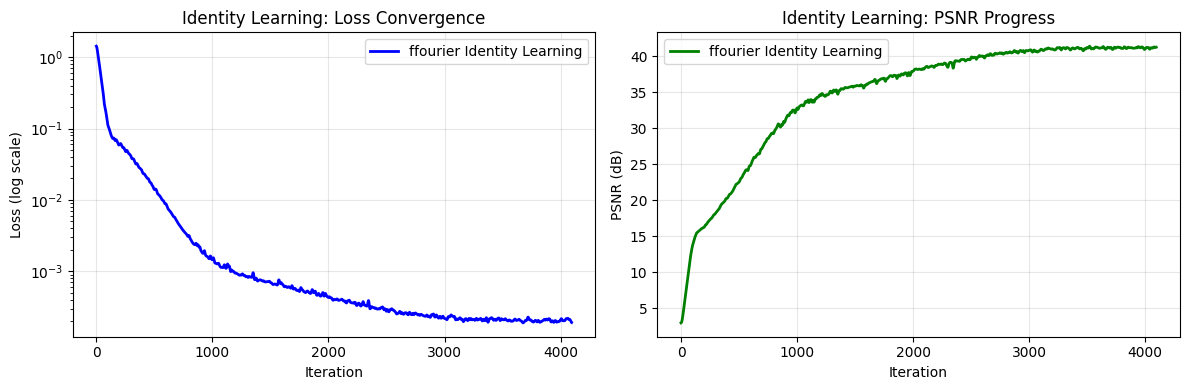

   Final Loss: 0.00017958
   Final PSNR: 41.42 dB
good


In [20]:
# Plot identity learning progress
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

iterations = np.arange(len(iterLosses))
losses = [loss[0] for loss in iterLosses]  # Extract first batch losses
psnrs = [psnr[0] for psnr in iterPSNRs]

# Smooth curves for better visualization
losses_smooth = gaussian_filter1d(losses, sigma=5)
psnrs_smooth = gaussian_filter1d(psnrs, sigma=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.semilogy(iterations, losses_smooth, 'b-', linewidth=2, label=f'{basisFunction} Identity Learning')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Identity Learning: Loss Convergence')
ax1.grid(True, alpha=0.3)
ax1.legend()

# PSNR curve
ax2.plot(iterations, psnrs_smooth, 'g-', linewidth=2, label=f'{basisFunction} Identity Learning')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Identity Learning: PSNR Progress')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluation
final_loss = losses[-1]
final_psnr = psnrs[-1]

print(f"   Final Loss: {final_loss:.8f}")
print(f"   Final PSNR: {final_psnr:.2f} dB")

if final_loss < 1e-4:
    print("excellent")
elif final_loss < 1e-2:
    print("good")
else:
    print("poor")


In [21]:
import h5py
import os

# Check what format we actually have
dataset_path = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
test_file = os.listdir(dataset_path)[0]
filepath = f'{dataset_path}/{test_file}'

print(f"File: {test_file}")

with h5py.File(filepath, 'r') as f:
    print("Root keys:", list(f.keys()))
    if 'config' in f:
        print("config:", list(f['config'].keys()))
    else:
        print("unknown format")

File: tgv_simulation_00050_2025-08-19_04-13-33.hdf5
Root keys: ['config', 'metadata', 'simulationExport']
config: ['boundary', 'compute', 'domain', 'fluid', 'kernel', 'neighborhood', 'particle', 'timestep']


In [22]:
import h5py
import os

# Check the actual config structure  
dataset_path = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
test_file = os.listdir(dataset_path)[0]
filepath = f'{dataset_path}/{test_file}'

with h5py.File(filepath, 'r') as f:
    if 'config' in f:
        def print_hdf5_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"{name}: {obj[()]}")
            else:
                print(f"{name}/ (group)")
        
        f['config'].visititems(print_hdf5_structure)

boundary/ (group)
compute/ (group)
domain/ (group)
fluid/ (group)
kernel/ (group)
neighborhood/ (group)
particle/ (group)
timestep/ (group)


In [23]:
# Test what the network actually learns
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.features import getFeatures

# Load a sample frame
sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(
    sample_idx, train_ds, hyperParameterDict, unrollLength=0
)

# Check input features (constant:1)
input_features = getFeatures(['constant:1'], currentState, [priorState], 'fluid', 
                            config, hyperParameterDict.get('dt', 0.01), verbose=True)
print(f"Input features shape: {input_features.shape}")
print(f"Input values: [{input_features.min():.6f}, {input_features.max():.6f}]")

# Check target (compute[rho]:constant:1/constant:rho0)
target_features = getFeatures(['compute[rho]:constant:1/constant:rho0'], currentState, [priorState], 'fluid',
                             config, hyperParameterDict.get('dt', 0.01), verbose=True)
print(f"Target features shape: {target_features.shape}")
print(f"Target values: [{target_features.min():.6f}, {target_features.max():.6f}]")

# Compare with raw density
raw_density = currentState['fluid']['densities']
rho0 = config['fluid']['rho0']
print(f"Raw density: [{raw_density.min():.6f}, {raw_density.max():.6f}]")
print(f"rho0: {rho0}")
print(f"Raw/rho0: [{(raw_density/rho0).min():.6f}, {(raw_density/rho0).max():.6f}]")

Processing feature (main loop): constant:1
Processing constant operation: constant@1
Constant =  1.0
Input features shape: torch.Size([2500, 1])
Input values: [1.000000, 1.000000]
Processing feature (main loop): compute[rho]:constant:1/constant:rho0
Processing arithmetic operation: compute[rho]@constant@1/constant@rho0
Input Operands:  ['compute[rho]@constant@1', 'constant@rho0']
Processing compute operation: compute[rho]@constant@1
Arguments: rho constant@1
Looking up feature: constant@1
Processing constant operation: constant@1
Constant =  1.0
Processing constant operation: constant@rho0
Constant =  1000.0
Target features shape: torch.Size([2500, 1])
Target values: [1.082512, 1.367861]
Raw density: [1058318.750000, 2516312.000000]
rho0: 1000.0
Raw/rho0: [1058.318848, 2516.312012]


In [24]:
from BasisConvolution.util.features import getFeatures

sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(
    sample_idx, train_ds, hyperParameterDict, unrollLength=0
)

print("density representations:")

# 1. Raw density 
raw_density = currentState['fluid']['densities']
print(f"1. Raw density: [{raw_density.min():.1f}, {raw_density.max():.1f}]")

# 2. Raw density normalized
rho0 = config['fluid']['rho0']
raw_normalized = raw_density / rho0
print(f"2. Raw/rho0: [{raw_normalized.min():.3f}, {raw_normalized.max():.3f}]")

# 3. SPH density of constant:1 (what network learns)
sph_density = getFeatures(['compute[rho]:constant:1'], currentState, [priorState], 'fluid',
                         config, hyperParameterDict.get('dt', 0.01))
print(f"3. SPH(constant:1): [{sph_density.min():.6f}, {sph_density.max():.6f}]")

# 4. Target (SPH density normalized)
target = getFeatures(['compute[rho]:constant:1/constant:rho0'], currentState, [priorState], 'fluid',
                    config, hyperParameterDict.get('dt', 0.01))
print(f"4. Target (SPH/rho0): [{target.min():.6f}, {target.max():.6f}]")

density representations:
1. Raw density: [1058318.8, 2516312.0]
2. Raw/rho0: [1058.319, 2516.312]
3. SPH(constant:1): [1082.512085, 1367.861328]
4. Target (SPH/rho0): [1.082512, 1.367861]


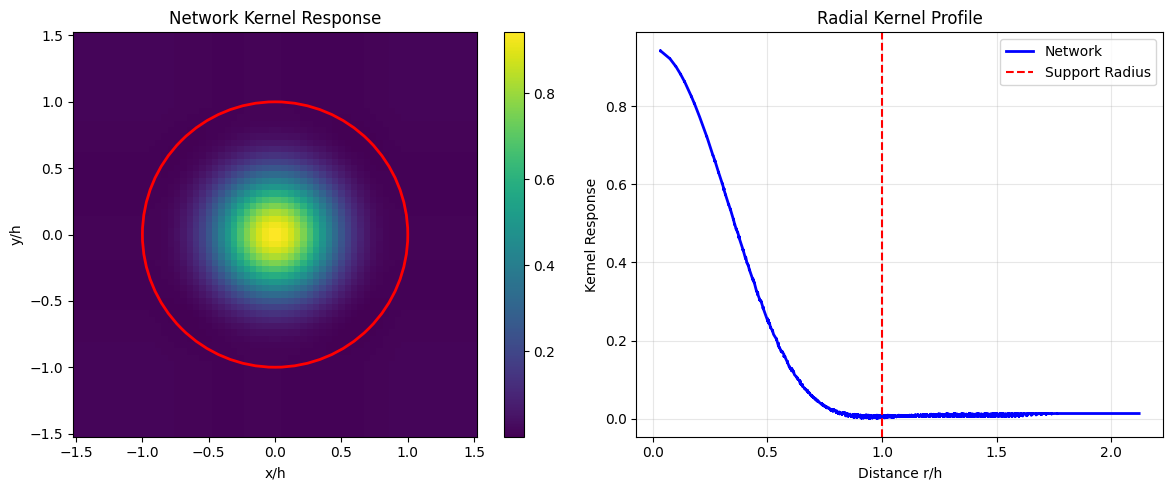

Kernel Analysis:
  Center response: 0.008743
  Max response: 0.941480
  Min response: 0.000907
  Response range: 0.940573
  Inside support (r≤1): 0.173452
  Outside support (r>1): 0.009713
  Localization ratio: 0.055997


In [25]:
# Test if network learned proper SPH kernel behavior
import torch
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic test: single particle at center, empty elsewhere
nx = 64
xx = np.linspace(-1.5, 1.5, nx)
yy = np.linspace(-1.5, 1.5, nx)
X, Y = np.meshgrid(xx, yy)
positions = torch.tensor(np.stack([X.flatten(), Y.flatten()]).T, 
                        device=currentState['fluid']['positions'].device, 
                        dtype=currentState['fluid']['positions'].dtype)

# Central particle position
center_pos = torch.tensor([[0.0, 0.0]], 
                         device=currentState['fluid']['positions'].device, 
                         dtype=currentState['fluid']['positions'].dtype)

# Compute distances from all grid points to center
distances = torch.norm(positions - center_pos, dim=1, keepdim=True)
relative_positions = positions - center_pos

# Create neighbor indices (all points neighbor to center)
synthetic_i = torch.arange(positions.shape[0], device=positions.device, dtype=torch.long)
synthetic_j = torch.zeros_like(synthetic_i)  # All point to center particle

# Test 1: Single particle response (proper SPH kernel test)
single_particle_features = torch.ones(positions.shape[0], 1, 
                                     device=positions.device, 
                                     dtype=positions.dtype)

# Run through network
model.eval()
with torch.no_grad():
    kernel_response = model(single_particle_features, synthetic_i, synthetic_j, 
                           relative_positions, verbose=False)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Network response
kernel_2d = kernel_response[:,0].cpu().numpy().reshape(nx, nx)
im1 = ax1.pcolormesh(X, Y, kernel_2d, cmap='viridis')
circle = plt.Circle((0, 0), 1.0, color='r', fill=False, linewidth=2)  # Support radius
ax1.add_artist(circle)
ax1.set_aspect('equal')
ax1.set_title('Network Kernel Response')
ax1.set_xlabel('x/h')
ax1.set_ylabel('y/h')
plt.colorbar(im1, ax=ax1)

# Plot 2: Radial profile
r = distances.cpu().numpy().flatten()
response = kernel_response[:,0].cpu().numpy().flatten()
sorted_idx = np.argsort(r)
ax2.plot(r[sorted_idx], response[sorted_idx], 'b-', linewidth=2, label='Network')
ax2.axvline(x=1.0, color='r', linestyle='--', label='Support Radius')
ax2.set_xlabel('Distance r/h')
ax2.set_ylabel('Kernel Response')
ax2.set_title('Radial Kernel Profile')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
max_response = kernel_response.max().item()
min_response = kernel_response.min().item()
center_response = kernel_response[nx*nx//2, 0].item()  # Center point response

print(f"Kernel Analysis:")
print(f"  Center response: {center_response:.6f}")
print(f"  Max response: {max_response:.6f}")
print(f"  Min response: {min_response:.6f}")
print(f"  Response range: {max_response - min_response:.6f}")

# Check if it's localized (SPH-like)
support_mask = r <= 1.0
inside_support = response[support_mask].mean()
outside_support = response[~support_mask].mean()

print(f"  Inside support (r≤1): {inside_support:.6f}")
print(f"  Outside support (r>1): {outside_support:.6f}")
print(f"  Localization ratio: {outside_support/inside_support:.6f}")

In [28]:
# Switch to evaluation mode
model.eval()

# Test on validation data - reuse your existing train_loader
identity_predictions = []
ground_truth_targets = []

with torch.no_grad():
    # Reset iterator
    train_iter = iter(train_loader)
    
    for i in range(5):  # Test first 5 batches
        try:
            bdata = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            bdata = next(train_iter)
            
        # Load batch using your existing functions
        configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(
            bdata, train_ds, hyperParameterDict, unrollLength=0)
        
        # Get ground truth targets (same as training)
        gt_targets = [traj[0]['fluid']['target'] for traj in trajectoryStates]
        
        # Forward pass with our trained identity kernel
        predictions = runInference(currentStates, configs, model, verbose=False)
        
        # Store results
        for pred, gt in zip(predictions, gt_targets):
            identity_predictions.append(pred.cpu().numpy())
            ground_truth_targets.append(gt.cpu().numpy())
        
        print(f"Batch {i+1}:")
        print(f"  Identity pred range: [{predictions[0].min():.3f}, {predictions[0].max():.3f}]")
        print(f"  Ground truth range: [{gt_targets[0].min():.3f}, {gt_targets[0].max():.3f}]")

# Combine all results
identity_all = np.concatenate(identity_predictions)
gt_all = np.concatenate(ground_truth_targets)

print(f"   Identity prediction range: [{identity_all.min():.3f}, {identity_all.max():.3f}]")
print(f"   Ground truth range: [{gt_all.min():.3f}, {gt_all.max():.3f}]")
print(f"   Mean difference: {abs(identity_all.mean() - gt_all.mean()):.6f}")
print(f"   RMSE: {np.sqrt(np.mean((identity_all - gt_all)**2)):.6f}")

# Key check: Does identity kernel produce reasonable density range?
if identity_all.max() <= 2.0 and identity_all.min() >= 0.8:
    print("\nIDENTITY KERNEL PRODUCES REASONABLE DENSITY RANGE!")
else:
    print(f"\nIdentity kernel shows unusual range: [{identity_all.min():.3f}, {identity_all.max():.3f}]")

Batch 1:
  Identity pred range: [0.976, 1.665]
  Ground truth range: [1.063, 1.661]
Batch 2:
  Identity pred range: [0.991, 1.679]
  Ground truth range: [1.073, 1.714]
Batch 3:
  Identity pred range: [1.011, 1.502]
  Ground truth range: [1.092, 1.485]
Batch 4:
  Identity pred range: [0.959, 1.876]
  Ground truth range: [1.060, 1.892]
Batch 5:
  Identity pred range: [1.001, 1.642]
  Ground truth range: [1.079, 1.624]
   Identity prediction range: [0.959, 1.876]
   Ground truth range: [1.060, 1.892]
   Mean difference: 0.000622
   RMSE: 0.014845

IDENTITY KERNEL PRODUCES REASONABLE DENSITY RANGE!


In [40]:
# Setup temporal training exactly like lagrangebench training notebook
temporal_datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
temporal_basisFunction = 'ffourier'
temporal_basisTerms = 4
temporal_windowFunction = 'None'

# Normal temporal training setup (like lagrangebench notebook)
temporal_args = parser.parse_args(shlex.split(
    f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 '
    f'--boundary False --basisFunctions {temporal_basisFunction} --basisTerms {temporal_basisTerms} '
    f'--windowFunction {temporal_windowFunction} --maxUnroll 1 --frameDistance 1 --epochs 5'
))

temporal_hyperParams = parseHyperParameters(temporal_args, None)
temporal_hyperParams['device'] = 'cuda'
temporal_hyperParams['iterations'] = 100  # Short training to monitor explosion

# Load dataset for temporal training
temporal_ds = datasetLoader(processFolder(temporal_hyperParams, temporal_datasetPath))
temporal_loader = DataLoader(temporal_ds, shuffle=True, batch_size=temporal_hyperParams['batchSize']).batch_sampler
temporal_iter = iter(temporal_loader)

finalizeHyperParameters(temporal_hyperParams, temporal_ds)

# Build temporal model and copy our good identity weights
temporal_model, temporal_optimizer, temporal_scheduler = buildModel(temporal_hyperParams, verbose=False)
temporal_model.load_state_dict(model.state_dict())  # Start from working identity kernel
temporal_model = temporal_model.train()

In [46]:
# Exact replication of training_lagrangebench.ipynb for ffourier only
print("🧪 EXACT REPLICATION - training_lagrangebench.ipynb")
print("Training ffourier with SAME setup that produced 2-8 range...")

# Exact setup from training_lagrangebench.ipynb
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

# EXACT args from training_lagrangebench.ipynb
args = parser.parse_args(shlex.split(
    f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 '
    f'--boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} '
    f'--windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'
))

# EXACT hyperparameters from training_lagrangebench.ipynb
exact_hyperParams = parseHyperParameters(args, None)
exact_hyperParams['device'] = 'cuda'
exact_hyperParams['iterations'] = 2**10  # 1024 iterations (vs our 100)
exact_hyperParams['batchSize'] = 8        # Batch size 8 (vs default)

# EXACT dataset loading
exact_ds = datasetLoader(processFolder(exact_hyperParams, datasetPath))
exact_loader = DataLoader(exact_ds, shuffle=True, batch_size=exact_hyperParams['batchSize']).batch_sampler
exact_iter = iter(exact_loader)

finalizeHyperParameters(exact_hyperParams, exact_ds)

print(f"Exact setup: {exact_hyperParams['iterations']} iterations, batch size {exact_hyperParams['batchSize']}")

# Build model with EXACT same settings
exact_model, exact_optimizer, exact_scheduler = buildModel(exact_hyperParams, verbose=False)
exact_model = exact_model.train()

print("Starting training with exact lagrangebench setup...")

# Exact training loop from training_lagrangebench.ipynb with output monitoring
print("🧪 RUNNING EXACT TRAINING LOOP WITH MONITORING")

iterLosses = []
iterPSNRs = []
bdatas = []

# Monitor output ranges during exact training
output_ranges = []

for i in range(exact_hyperParams['totalIterations']):  # Full 1024 iterations
    try:
        bdata = next(exact_iter)
    except StopIteration:
        exact_iter = iter(exact_loader)
        bdata = next(exact_iter)
    
    bdatas.append(bdata)
    
    # EXACT loadAugmentedBatch call from training_lagrangebench.ipynb
    configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(
        bdata, exact_ds, exact_hyperParams, unrollLength=0)
    
    exact_optimizer.zero_grad()
    predictions = runInference(currentStates, configs, exact_model, verbose=False)
    
    # EXACT target extraction from training_lagrangebench.ipynb
    gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]
    
    # Monitor outputs before loss computation
    pred_min = predictions[0].min().item()
    pred_max = predictions[0].max().item()
    output_ranges.append([pred_min, pred_max])
    
    # Print every 100 iterations
    if i % 100 == 0:
        print(f"Iter {i:4d}: Pred[{pred_min:7.3f}, {pred_max:7.3f}]")
    
    # Check for explosion
    if abs(pred_max) > 5.0 or abs(pred_min) < -5.0:
        print(f"🚨 EXPLOSION DETECTED at iteration {i}!")
        print(f"   Range: [{pred_min:.1f}, {pred_max:.1f}]")
        break
    
    # EXACT loss computation from training_lagrangebench.ipynb
    losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
    psnrs = [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss) for gt, loss in zip(gts, losses)]
    
    loss = torch.stack(losses).mean()
    loss.backward()
    psnr = torch.stack(psnrs).mean()
    
    iterLosses.append([l.item() for l in losses])
    iterPSNRs.append([p.item() for p in psnrs])
    
    exact_optimizer.step()

print(f"\nFinal training range: [{output_ranges[-1][0]:.3f}, {output_ranges[-1][1]:.3f}]")
print(f"Final loss: {iterLosses[-1][0]:.8f}")

🧪 EXACT REPLICATION - training_lagrangebench.ipynb
Training ffourier with SAME setup that produced 2-8 range...
Unroll length  1  exceeds maximum, limiting to 0
Exact setup: 1024 iterations, batch size 8
Starting training with exact lagrangebench setup...
🧪 RUNNING EXACT TRAINING LOOP WITH MONITORING
Iter    0: Pred[ -0.028,   0.159]
Iter  100: Pred[  0.600,   1.944]
Iter  200: Pred[  0.800,   1.733]
Iter  300: Pred[  0.974,   1.590]
Iter  400: Pred[  1.009,   1.686]
Iter  500: Pred[  0.964,   1.757]
Iter  600: Pred[  1.015,   1.580]
Iter  700: Pred[  0.984,   1.738]
Iter  800: Pred[  0.995,   1.751]
Iter  900: Pred[  0.991,   1.694]
Iter 1000: Pred[  0.999,   1.495]

Final training range: [0.977, 1.622]
Final loss: 0.00042957
